# MFEM101: solving a PDE with hIPPyMFEM

This tutorial introduces the forward-problem layer of hIPPyMFEM: meshes and finite
element spaces from [MFEM](https://mfem.org), boundary conditions, and a PDE written as
a *residual density* that the library differentiates for you. It follows hIPPYlib's
*FEniCS101* tutorial and solves the same problem, so the two can be read side by side.

We consider the boundary value problem (BVP)

$$
\begin{aligned}
-\nabla \cdot (k \nabla u) &= f && \text{in } \Omega,\\
u &= u_0 && \text{on } \Gamma_D = \Gamma_{\rm left} \cup \Gamma_{\rm right},\\
k \frac{\partial u}{\partial \mathbf{n}} &= \sigma && \text{on } \Gamma_N = \Gamma_{\rm top} \cup \Gamma_{\rm bottom},
\end{aligned}
$$

where $\Omega = (0,1) \times (0,1)$, and $\Gamma_D$ and $\Gamma_N$ are the union of the
left and right, and of the top and bottom boundaries of $\Omega$, respectively. Here

$$
\begin{aligned}
k(x,y) &= 1 && \text{in } \Omega,\\
f(x,y) &= \left(4\pi^2+\frac{\pi^2}{4}\right)\sin(2 \pi x) \sin\left(\frac{\pi}{2} y\right) && \text{in } \Omega,\\
u_0(x,y) &= 0 && \text{on } \Gamma_D,\\
\sigma(x) &= -\frac{\pi}{2}\sin(2 \pi x) \text{ on } \Gamma_{\rm bottom}, \qquad \sigma = 0 && \text{on } \Gamma_{\rm top}.
\end{aligned}
$$

The exact solution is

$$ u_e(x,y) = \sin(2\pi x)\sin\left(\frac{\pi}{2}y\right). $$

## Weak formulation

Let us define the Hilbert spaces $V_{u_0}, V_0 \subset H^1(\Omega)$ as

$$ V_{u_0} := \left\{ v \in H^1(\Omega) \text{ s.t. } v = u_0 \text{ on } \Gamma_D \right\}, \qquad
   V_{0} := \left\{ v \in H^1(\Omega) \text{ s.t. } v = 0 \text{ on } \Gamma_D \right\}. $$

To obtain the weak formulation, we multiply the PDE by an arbitrary function $p \in V_0$
and integrate over the domain $\Omega$:

$$ -\int_{\Omega} \nabla \cdot (k \nabla u)\, p \, dx = \int_\Omega f p \, dx\quad \forall \; p \in V_0. $$

Integrating by parts the term with second derivatives gives

$$ \int_{\Omega} k \nabla u \cdot \nabla p \, dx - \int_{\partial \Omega} k \frac{\partial u}{\partial \mathbf{n}} p \, ds = \int_\Omega f p \, dx \quad \forall \; p \in V_0, $$

and since $p = 0$ on $\Gamma_D$ and $k\, \partial u / \partial \mathbf{n} = \sigma$ on
$\Gamma_N$, the weak formulation reads:

*Find* $u \in V_{u_0}$ *such that*

$$ \int_{\Omega} k \nabla u \cdot \nabla p \, dx - \int_\Omega f p \, dx - \int_{\Gamma_N} \sigma p \, ds = 0 \quad \forall \; p \in V_0. $$

hIPPYlib names the test function $v$; we call it $p$ because in an inverse problem it
becomes the adjoint variable.

## Residual densities

hIPPyMFEM has no form language. The weak form is written as two Python functions of
the fields **at one quadrature point**,

$$ r(u, k, p; x) = k\, \nabla u \cdot \nabla p - f\, p, \qquad r_\Gamma(u, k, p; x, \mathbf{n}) = -\sigma\, p, $$

so that the residual is $R(u, k, p) = \int_\Omega r \, dx + \int_{\Gamma_N} r_\Gamma \, ds$.
Each field argument carries its value (`.val`) and gradient (`.grad`) at the point, `x`
is the point, and $\mathbf{n}$ the outward unit normal. The library evaluates a density
at every quadrature point of every element with JAX, and every operator it needs,
starting with the Jacobian $\partial R / \partial u$ that the finite element system is
made of, comes from differentiating these functions. MFEM then assembles in parallel.

Here $k$ occupies the *parameter* slot. That is the only reason it is a field rather
than a constant: in the following tutorials the parameter is the unknown of the inverse
problem.

## 1. Load modules

To start we load the following modules:

- `mfem.par`: the parallel Python interface to MFEM ([PyMFEM](https://github.com/mfem/PyMFEM));
- `mpi4py`: MPI. A notebook runs on one rank; the same code runs under `mpirun`;
- `hippymfem`, and `hippymfem.nb` for plotting;
- `jax` and `jax.numpy`: automatic differentiation, used to write densities;
- [numpy](https://numpy.org) and [matplotlib](https://matplotlib.org).

In [1]:
import math
import os
import sys

# Run from a source checkout without installing: the repository root is one level up.
sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb

import jax
import jax.numpy as jnp

mfem.Hypre.Init()
print("hIPPyMFEM", hm.__version__, "on", MPI.COMM_WORLD.size, "MPI rank(s)")

hIPPyMFEM 0.1.0 on 1 MPI rank(s)


## 2. Define the mesh and the finite element space

We triangulate $\Omega = [0, 1]^2$ with `n` squares per side, each cut into two
triangles, and distribute the mesh over the MPI ranks with `mfem.ParMesh`.

On it, `hm.FunctionSpace.H1(mesh, degree)` is the space $V_h \subset H^1(\Omega)$ of
continuous piecewise polynomials of degree `degree`.

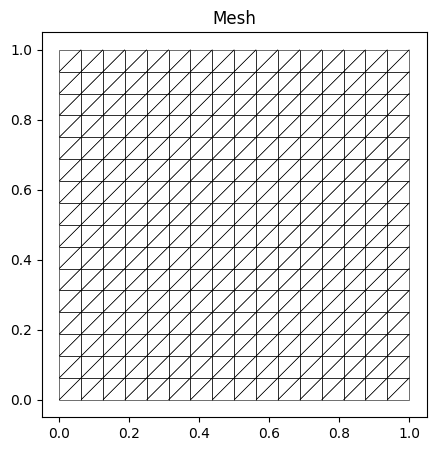

dim(Vh) = 289


In [2]:
n = 16
degree = 1
mesh = mfem.ParMesh(MPI.COMM_WORLD,
                    mfem.Mesh.MakeCartesian2D(n, n, mfem.Element.TRIANGLE))

plt.figure(figsize=(5, 5))
nb.plot(mesh, mytitle="Mesh", show_axis="on")
plt.show()

Vh = hm.FunctionSpace.H1(mesh, degree)
print("dim(Vh) =", Vh.GlobalTrueVSize())

## 3. Define boundary labels

MFEM meshes carry an integer *attribute* on every boundary element. Boundary
conditions and boundary integrals select their part of $\partial\Omega$ by attribute,
so there is nothing to mark by hand. `MakeCartesian2D` numbers the sides
counterclockwise from the bottom: 1 bottom, 2 right, 3 top, 4 left. A mesh read from a
file carries the attributes its generator wrote.

In [3]:
bottom, right, top, left = 1, 2, 3, 4
print("boundary attributes of the mesh:", sorted(set(mesh.bdr_attributes.ToList())))

boundary attributes of the mesh: [1, 2, 3, 4]


## 4. Define the coefficients of the PDE and the boundary conditions

Coefficients are Python functions of the point `x`, written with `jax.numpy` so that
they can be evaluated, and differentiated, inside a density.

Dirichlet conditions, also called *essential* conditions, are imposed on the space:
`hm.DirichletBC` takes the value and the boundary attributes. Neumann conditions are
*natural* conditions: they enter the weak form, here as the boundary density
$r_\Gamma$.

In [4]:
def f(x):
    return ((4.0 * jnp.pi**2 + jnp.pi**2 / 4.0)
            * jnp.sin(2.0 * jnp.pi * x[0]) * jnp.sin(0.5 * jnp.pi * x[1]))


def sigma(x):
    # -pi/2 sin(2 pi x) on the bottom edge (y = 0), zero on the top edge (y = 1)
    return jnp.where(x[1] < 0.5, -0.5 * jnp.pi * jnp.sin(2.0 * jnp.pi * x[0]), 0.0)


bc = hm.DirichletBC(Vh, 0.0, bdr_attributes=[left, right])

## 5. Define and solve the variational problem

A hIPPyMFEM problem is defined on three spaces, `[STATE, PARAMETER, ADJOINT]`, the
structure an inverse problem needs. Here the state is $u$, the parameter is the
coefficient $k$ (a P1 field equal to one), and the adjoint slot holds the test
function $p$.

Writing $u_h = \sum_j \mathrm{u}_j \phi_j$ and testing with every basis function
$\phi_i$ turns $R(u_h, k, \phi_i) = 0$ into the linear system

$$ A\, \mathrm{u} = \mathrm{b}, \qquad A_{ij} = \frac{\partial R(u_h, k, \phi_i)}{\partial \mathrm{u}_j}. $$

`PDEVariationalProblem` assembles $A$ by differentiating the density, eliminates the
Dirichlet conditions, and solves. With `is_fwd_linear=True` it takes a single Newton
step, which is exact for a linear problem. The linear solver defaults to GMRES
preconditioned by algebraic multigrid (hypre's BoomerAMG) with a relative tolerance of
$10^{-12}$; any solver can be assigned to `pde.solver` instead.

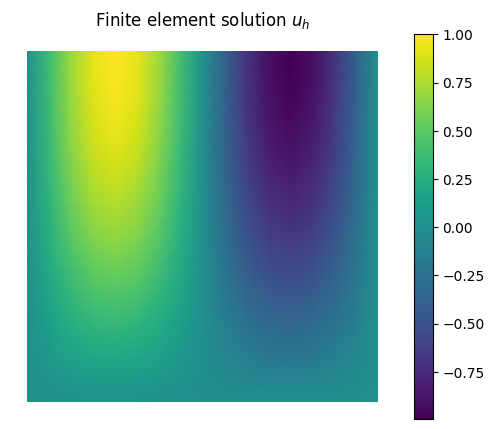

In [5]:
Vk = hm.FunctionSpace.H1(mesh, 1)
k = Vk.project(lambda x: 1.0)


def residual(u, k, p, x):
    return k.val * hm.inner(u.grad, p.grad) - f(x) * p.val


def neumann(u, k, p, x, normal):
    return -sigma(x) * p.val


pde = hm.PDEVariationalProblem([Vh, Vk, Vh], residual, bc, bc.homogeneous(),
                               is_fwd_linear=True,
                               bdr_varf=neumann, bdr_attributes=[bottom, top])
uh = pde.generate_state()
pde.solveFwd(uh, [uh, k, None])

plt.figure(figsize=(6, 5))
nb.plot(Vh, uh, mytitle="Finite element solution $u_h$")
plt.show()

## 6. Compute the discretization error

For this problem the exact solution is known, so we can compute the norms of the
discretization error

$$ \| u_e - u_h \|_{L^2(\Omega)} := \left( \int_{\Omega} (u_e - u_h)^2 \, dx \right)^{1/2},
\qquad
\| u_e - u_h \|_{H^1(\Omega)} := \left( \int_{\Omega} (u_e - u_h)^2 \, dx + \int_{\Omega} |\nabla u_e - \nabla u_h|^2 \, dx \right)^{1/2}. $$

Both integrals are densities again. `hm.VariationalQoi` integrates a density
$q(u, k; x)$ over the mesh (and, in an inverse problem, differentiates it). The exact
gradient comes from `jax.grad` of the exact solution rather than from differentiating
by hand.

In [6]:
def u_e(x):
    return jnp.sin(2.0 * jnp.pi * x[0]) * jnp.sin(0.5 * jnp.pi * x[1])


grad_u_e = jax.grad(u_e)          # the exact gradient, by automatic differentiation


def l2_error_density(u, k, x):
    return (u.val - u_e(x)) ** 2


def grad_error_density(u, k, x):
    d = u.grad - grad_u_e(x)
    return hm.inner(d, d)


def errors(Vh, Vk, uh, k):
    spaces, point = [Vh, Vk, Vh], [uh, k, None]
    qdeg = 2 * Vh.order + 4       # a quadrature rule well above the integrand's degree
    err_L2 = math.sqrt(hm.VariationalQoi(spaces, l2_error_density, qdeg).eval(point))
    err_grad = math.sqrt(hm.VariationalQoi(spaces, grad_error_density, qdeg).eval(point))
    return err_L2, math.sqrt(err_L2**2 + err_grad**2)


err_L2, err_H1 = errors(Vh, Vk, uh, k)
print("|| u_h - u_e ||_L2 =", err_L2)
print("|| u_h - u_e ||_H1 =", err_H1)

|| u_h - u_e ||_L2 = 0.008805217978842267
|| u_h - u_e ||_H1 = 0.39671895152205844


## 7. Convergence of the finite element method

We now verify numerically a well-known convergence result for the finite element
method.

Let $s$ denote the polynomial degree of the finite element space, and assume that the
solution $u_e$ is at least in $H^{s+1}(\Omega)$. Then

$$ \| u_e - u_h \|_{H^1} \leq C h^{s}, \qquad \| u_e - u_h \|_{L^2} \leq C h^{s+1}. $$

The function `compute(n, degree)` below solves the problem on a mesh with `n` elements
per side and polynomial degree `degree`, and returns both errors. The figure shows them
against the mesh size $h = 1/n$ for piecewise linear (P1, $s = 1$) and piecewise
quadratic (P2, $s = 2$) elements, and the numbers agree with the theory:

- for P1 elements, first order convergence in the $H^1$ norm and second order in the $L^2$ norm;
- for P2 elements, second order in the $H^1$ norm and third order in the $L^2$ norm.

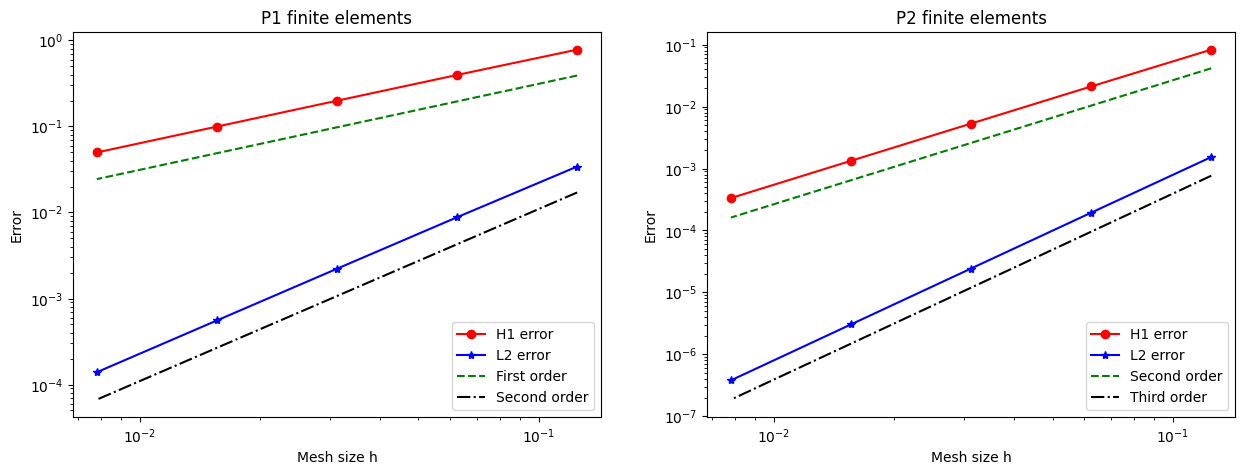

observed orders  P1:  H1 [0.98 0.99 1.   1.  ]   L2 [1.96 1.99 2.   2.  ]
                 P2:  H1 [1.97 1.99 2.   2.  ]   L2 [2.98 2.99 3.   3.  ]


In [7]:
def compute(n, degree):
    mesh = mfem.ParMesh(MPI.COMM_WORLD,
                        mfem.Mesh.MakeCartesian2D(n, n, mfem.Element.TRIANGLE))
    Vh = hm.FunctionSpace.H1(mesh, degree)
    Vk = hm.FunctionSpace.H1(mesh, 1)
    k = Vk.project(lambda x: 1.0)
    bc = hm.DirichletBC(Vh, 0.0, bdr_attributes=[left, right])
    pde = hm.PDEVariationalProblem([Vh, Vk, Vh], residual, bc, bc.homogeneous(),
                                   is_fwd_linear=True,
                                   bdr_varf=neumann, bdr_attributes=[bottom, top])
    uh = pde.generate_state()
    pde.solveFwd(uh, [uh, k, None])
    return errors(Vh, Vk, uh, k)


nref = 5
n = 8 * np.power(2, np.arange(0, nref))
h = 1.0 / n

err_L2_P1, err_H1_P1 = np.zeros(nref), np.zeros(nref)
err_L2_P2, err_H1_P2 = np.zeros(nref), np.zeros(nref)
for i in range(nref):
    err_L2_P1[i], err_H1_P1[i] = compute(n[i], 1)
    err_L2_P2[i], err_H1_P2[i] = compute(n[i], 2)

plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.loglog(h, err_H1_P1, "-or", label="H1 error")
plt.loglog(h, err_L2_P1, "-*b", label="L2 error")
plt.loglog(h, 0.5 * err_H1_P1[0] * (h / h[0]), "--g", label="First order")
plt.loglog(h, 0.5 * err_L2_P1[0] * (h / h[0]) ** 2, "-.k", label="Second order")
plt.xlabel("Mesh size h")
plt.ylabel("Error")
plt.title("P1 finite elements")
plt.legend(loc="lower right")

plt.subplot(122)
plt.loglog(h, err_H1_P2, "-or", label="H1 error")
plt.loglog(h, err_L2_P2, "-*b", label="L2 error")
plt.loglog(h, 0.5 * err_H1_P2[0] * (h / h[0]) ** 2, "--g", label="Second order")
plt.loglog(h, 0.5 * err_L2_P2[0] * (h / h[0]) ** 3, "-.k", label="Third order")
plt.xlabel("Mesh size h")
plt.ylabel("Error")
plt.title("P2 finite elements")
plt.legend(loc="lower right")
plt.show()


def rates(err):
    return np.round(np.log2(err[:-1] / err[1:]), 2)


print("observed orders  P1:  H1", rates(err_H1_P1), "  L2", rates(err_L2_P1))
print("                 P2:  H1", rates(err_H1_P2), "  L2", rates(err_L2_P2))

## 8. A nonlinear problem, with nothing more to write

Nothing above relied on the problem being linear. Let the conductivity depend on the
solution,

$$ -\nabla \cdot \left( (1 + u^2)\, \nabla u \right) = f_{\rm nl} \quad \text{in } \Omega, $$

with the same kind of boundary conditions and the same exact solution $u_e$. With a
form language one derives the Jacobian of the weak form, or asks the form compiler for
it; here the density is still the only input, and `is_fwd_linear=False` turns the solve
into Newton's method with a line search.

The source term $f_{\rm nl} = -\nabla \cdot ((1 + u_e^2)\nabla u_e)$ and the Neumann
flux $(1 + u_e^2)\nabla u_e \cdot \mathbf{n}$ follow from $u_e$. Rather than derive them
on paper, we let JAX differentiate $u_e$ twice. The boundary density uses the normal it
is given, so one expression serves the top and the bottom edges.

In [8]:
def conductivity(u):
    return 1.0 + u ** 2


def flux_e(x):                    # (1 + u_e^2) grad u_e
    return conductivity(u_e(x)) * grad_u_e(x)


def f_nl(x):                      # -div((1 + u_e^2) grad u_e)
    return -jnp.trace(jax.jacfwd(flux_e)(x))


def residual_nl(u, k, p, x):
    return conductivity(u.val) * hm.inner(u.grad, p.grad) - f_nl(x) * p.val


def neumann_nl(u, k, p, x, normal):
    return -jnp.dot(flux_e(x), normal) * p.val


mesh = mfem.ParMesh(MPI.COMM_WORLD,
                    mfem.Mesh.MakeCartesian2D(32, 32, mfem.Element.TRIANGLE))
Vh = hm.FunctionSpace.H1(mesh, 2)
Vk = hm.FunctionSpace.H1(mesh, 1)
k = Vk.vector()                   # this density does not use the parameter
bc = hm.DirichletBC(Vh, 0.0, bdr_attributes=[left, right])
pde_nl = hm.PDEVariationalProblem([Vh, Vk, Vh], residual_nl, bc, bc.homogeneous(),
                                  is_fwd_linear=False,
                                  bdr_varf=neumann_nl, bdr_attributes=[bottom, top])
pde_nl.newton_parameters["print_level"] = 0
u_nl = pde_nl.generate_state()
pde_nl.solveFwd(u_nl, [u_nl, k, None])

err_L2, err_H1 = errors(Vh, Vk, u_nl, k)
print("Newton iterations:", pde_nl.fwd_iterations)
print("|| u_h - u_e ||_L2 = %.3e   (the linear problem, P2 at n = 32: %.3e)" % (err_L2, err_L2_P2[2]))
print("|| u_h - u_e ||_H1 = %.3e   (the linear problem, P2 at n = 32: %.3e)" % (err_H1, err_H1_P2[2]))

  fwd Newton  1: ||r|| = 2.250759e-01  alpha = 0.5


  fwd Newton  2: ||r|| = 9.201738e-02  alpha = 1


  fwd Newton  3: ||r|| = 3.335665e-03  alpha = 1


  fwd Newton  4: ||r|| = 3.569364e-06  alpha = 1


  fwd Newton  5: ||r|| = 3.262766e-12  alpha = 1


Newton iterations: 5
|| u_h - u_e ||_L2 = 2.436e-05   (the linear problem, P2 at n = 32: 2.436e-05)
|| u_h - u_e ||_H1 = 5.311e-03   (the linear problem, P2 at n = 32: 5.311e-03)


The errors match the P2 row of the convergence study at the same mesh size: Newton's
method solved the nonlinear discrete problem to its tolerance, with a Jacobian nobody
wrote.

The next tutorial, `02_PoissonDeterministic`, turns $k$ into an unknown and recovers it
from data.

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `1_FEniCS101`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).